# 1D PDE — Three-Zone Fishing Policy

This notebook is an alternative to `02_1d_pde.ipynb` that replaces the two-zone EEZ boundary
with a **three-tier regulatory structure** reflecting real maritime law:

| Zone | Distance | Fishing policy | Dimensionless h̃ |
|------|----------|---------------|------------------|
| Territorial waters | 0 – 12 mi | **MEY** — maximises economic yield | stochastic ≈ 0.05–0.22 |
| Exclusive Economic Zone | 12 – 200 mi | **MSY** — maximum sustainable yield | stochastic ≈ 0.45–0.55 |
| International waters | > 200 mi | **Unregulated** — maximum fishing | h̃ = 1 (fixed) |

With h̃ = 1 in the outer zone the PDE becomes  
∂x/∂τ = x(1−x) − x + δ ∂²x/∂ξ² = −x² + δ ∂²x/∂ξ² < 0 for x > 0,  
so the international population collapses to x* = 0 in isolation; it is sustained only by
diffusive spillover from the inner zones.

**Sections**
- **A** — Single-species logistic PDE with three-zone policy (sub-cases A.i / A.ii / A.iii)
- **B** — Two-species competing PDE with three-zone policy (sub-cases B.i / B.ii / B.iii)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from pde_solver import simulate_rd_fishing_3zone, simulate_competing_rd_fishing_3zone
from plotting import plot_snapshots, plot_heatmap, plot_snapshots_2s

# ── Shared dimensionless parameters ──────────────────────────────────────────
r_ref   = 0.5          # yr⁻¹  (growth rate used for timescale)
D_ref   = 10.0         # miles²/yr
L_ref   = 600.0        # miles  (domain length)
K       = 1.0          # dimensionless carrying capacity
r       = 1.0          # dimensionless growth rate (r/r_ref)
delta   = D_ref / (r_ref * L_ref**2)   # ≈ 5.556e-5

N = 301
xi  = np.linspace(0.0, 1.0, N)         # dimensionless position ξ ∈ [0, 1]
dxi = xi[1] - xi[0]

# Zone boundaries (dimensionless)
xi_terr = 12.0  / L_ref   # = 0.02   — territorial / EEZ
xi_eez  = 200.0 / L_ref   # = 1/3    — EEZ / international
h_intl  = 1.0             # fixed unregulated rate

T_end   = 100.0           # dimensionless time (τ = r_ref · t, 200 yr → τ=100)
snap_τ  = [0.0, 10.0, 25.0, 50.0, 100.0]

rng = np.random.default_rng(seed=42)

print(f"δ = {delta:.4e}")
print(f"Territorial boundary ξ₁ = {xi_terr:.4f}  ({12} miles)")
print(f"EEZ boundary         ξ₂ = {xi_eez:.4f}  ({200} miles)")
print(f"h̃_intl = {h_intl} (drives outer zone to x*=0)")

δ = 5.5556e-05
Territorial boundary ξ₁ = 0.0200  (12 miles)
EEZ boundary         ξ₂ = 0.3333  (200 miles)
h̃_intl = 1.0 (drives outer zone to x*=0)


In [2]:
# ── Stochastic annual harvest-rate schedules ──────────────────────────────────
# MEY:  h̃_MEY = (1 − √(1−f)) / 2,  f ~ Uniform[0.80, 0.90]
# MSY:  h̃_MSY ~ Uniform[0.45, 0.55]

n_years = int(T_end) + 2   # one entry per year 0, 1, …, T_end+1

def make_mey_schedule(n, rng_gen):
    f = rng_gen.uniform(0.80, 0.90, size=n)
    return 0.5 * (1.0 - np.sqrt(1.0 - f))

def make_msy_schedule(n, rng_gen):
    return rng_gen.uniform(0.45, 0.55, size=n)

# Single set of schedules shared by all Section-A sub-cases
h_terr_A = make_mey_schedule(n_years, rng)
h_eez_A  = make_msy_schedule(n_years, rng)

print(f"h̃_MEY  range: [{h_terr_A.min():.4f}, {h_terr_A.max():.4f}]  mean={h_terr_A.mean():.4f}")
print(f"h̃_MSY  range: [{h_eez_A.min():.4f}, {h_eez_A.max():.4f}]   mean={h_eez_A.mean():.4f}")
print(f"h̃_intl = {h_intl}  (outer zone, fixed)")

h̃_MEY  range: [0.2768, 0.3400]  mean=0.3067
h̃_MSY  range: [0.4522, 0.5492]   mean=0.4999
h̃_intl = 1.0  (outer zone, fixed)


In [3]:
# ── Plotting helpers ──────────────────────────────────────────────────────────

ZONE_COLORS = {'terr': '#2196F3', 'eez': '#FF9800', 'intl': '#F44336'}
ZONE_LABELS = {
    'terr': f'Territorial (0–12 mi)',
    'eez':  f'EEZ (12–200 mi)',
    'intl': f'International (>200 mi)',
}

def add_zone_lines(ax):
    """Add vertical dashed lines for the two zone boundaries."""
    ax.axvline(xi_terr, color='#2196F3', ls=':', lw=1.5, label=f'12-mile limit (ξ={xi_terr:.3f})')
    ax.axvline(xi_eez,  color='#FF9800', ls='--', lw=1.5, label=f'200-mile EEZ (ξ={xi_eez:.3f})')


def plot_3zone_biomass(res, title):
    """Plot total and per-zone biomass over time for a 3-zone single-species result."""
    τ = res['time']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(τ, res['B_terr'], color=ZONE_COLORS['terr'], lw=2, label=ZONE_LABELS['terr'])
    ax.plot(τ, res['B_eez'],  color=ZONE_COLORS['eez'],  lw=2, label=ZONE_LABELS['eez'])
    ax.plot(τ, res['B_intl'], color=ZONE_COLORS['intl'],  lw=2, label=ZONE_LABELS['intl'])
    ax.plot(τ, res['B_tot'],  'k--', lw=1.5, label='Total')
    ax.set_xlabel('Dimensionless time τ')
    ax.set_ylabel('Biomass (integrated density)')
    ax.set_title(f'Regional Biomass — {title}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.plot(τ, res['Catch'],    color='steelblue', lw=2, label='Instantaneous catch')
    ax.plot(τ, res['CumCatch'], color='darkblue',  lw=2, ls='--', label='Cumulative catch')
    ax.set_xlabel('Dimensionless time τ')
    ax.set_ylabel('Catch')
    ax.set_title(f'Catch — {title}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig


def plot_3zone_biomass_2s(res, title):
    """Per-zone biomass for two competing species."""
    τ = res['time']
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    zone_keys = [('B1_terr','B2_terr','terr'), ('B1_eez','B2_eez','eez'), ('B1_intl','B2_intl','intl')]
    zone_names = ['Territorial (0–12 mi)', 'EEZ (12–200 mi)', 'International (>200 mi)']
    for ax, (k1, k2, zkey), zname in zip(axes, zone_keys, zone_names):
        ax.plot(τ, res[k1], lw=2, label='Species 1')
        ax.plot(τ, res[k2], lw=2, ls='--', label='Species 2')
        ax.set_xlabel('τ')
        ax.set_ylabel('Biomass')
        ax.set_title(zname)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    fig.tight_layout()
    return fig


def plot_harvest_schedule(h_terr, h_eez, h_intl_val, T_end, title='Harvest-rate schedules'):
    """Step plot showing annual stochastic fishing rates by zone."""
    years = np.arange(len(h_terr))
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.step(years, h_terr, where='post', color=ZONE_COLORS['terr'], lw=2, label=f'h̃_MEY (territorial) — mean {h_terr.mean():.3f}')
    ax.step(years, h_eez,  where='post', color=ZONE_COLORS['eez'],  lw=2, label=f'h̃_MSY (EEZ) — mean {h_eez.mean():.3f}')
    ax.axhline(h_intl_val, color=ZONE_COLORS['intl'], lw=2, ls='--', label=f'h̃ = {h_intl_val} (international, fixed)')
    ax.set_xlim(0, min(T_end, len(h_terr)-1))
    ax.set_xlabel('Year')
    ax.set_ylabel('Dimensionless harvest rate h̃')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return fig


print('Helper functions defined.')

Helper functions defined.


---
## Section A — Single Species: Three-Zone Fishing Policy

PDE (dimensionless):
$$\frac{\partial x}{\partial \tau} = x(1-x) - \tilde{h}(\xi,\tau)\,x + \delta\,\frac{\partial^2 x}{\partial \xi^2}$$

**Expected equilibria** (without diffusion):
- Territorial: $x^* = 1 - \tilde{h}_{\text{MEY}} \approx 0.78$–$0.90$
- EEZ: $x^* = 1 - \tilde{h}_{\text{MSY}} \approx 0.50$
- International: $\partial x/\partial \tau = -x^2 < 0$ → $x^* = 0$  *(collapse zone)*

Diffusion creates spillover gradients at both boundaries. Fish diffusing outward from the EEZ
sustain a non-zero (but low) population in the international zone.

**Sub-cases** test attractor robustness with different initial fish locations:
- **A.i** — IC centred in territorial waters ($s = 6$ mi)
- **A.ii** — IC centred in EEZ ($s = 100$ mi)
- **A.iii** — IC centred in international waters ($s = 400$ mi)

In [4]:
# ── A.i  IC centred at s = 6 miles (territorial waters) ──────────────────────
res_Ai = simulate_rd_fishing_3zone(
    L=1.0, N=N,
    D=delta, r=1.0, K=K,
    T_end=T_end,
    s_boundary1=xi_terr,
    s_boundary2=xi_eez,
    h_terr_schedule=h_terr_A,
    h_eez_schedule=h_eez_A,
    h_intl=h_intl,
    gaussian_center=6.0/L_ref,     # ξ = 0.01
    gaussian_scale=50.0/L_ref,
    snapshot_times=snap_τ,
    store_full=True,
)
print(f"A.i  dt={res_Ai['dt']:.5f}  nt={res_Ai['nt']}  min(u)={res_Ai['min_u']:.4f}")

A.i  dt=0.04498  nt=2223  min(u)=0.0000


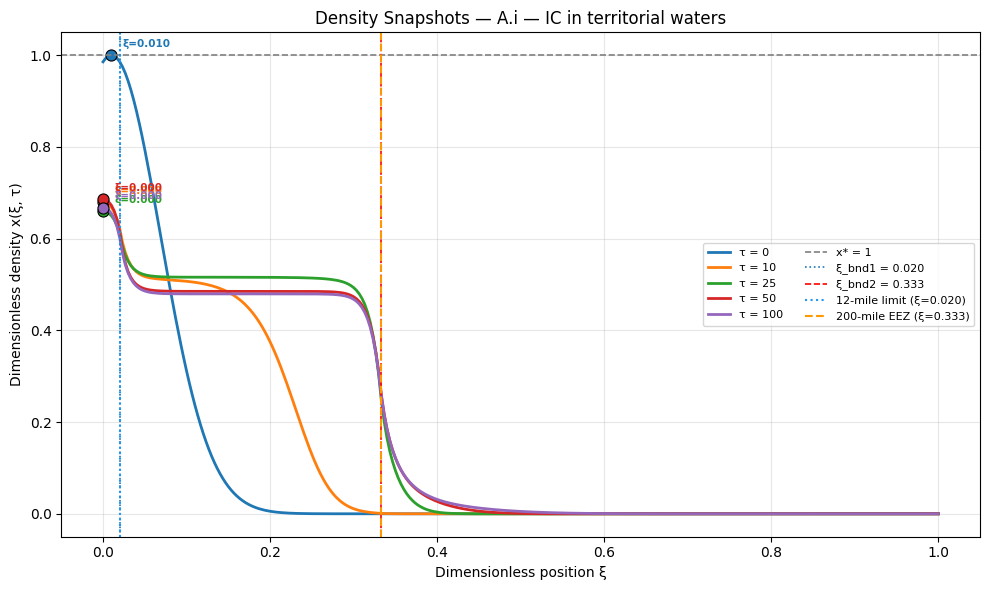

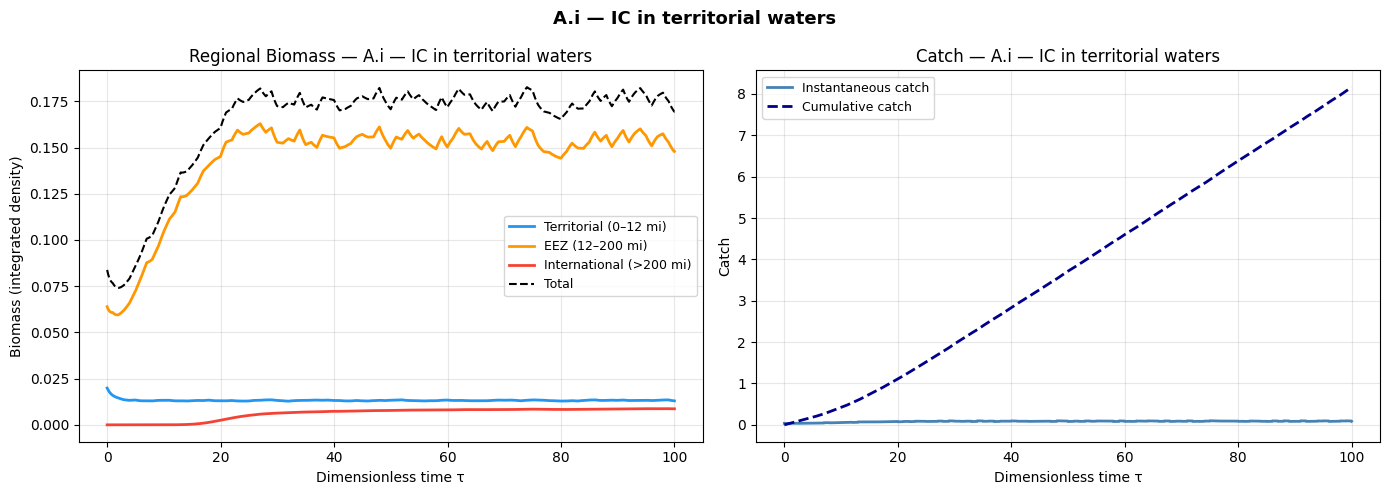

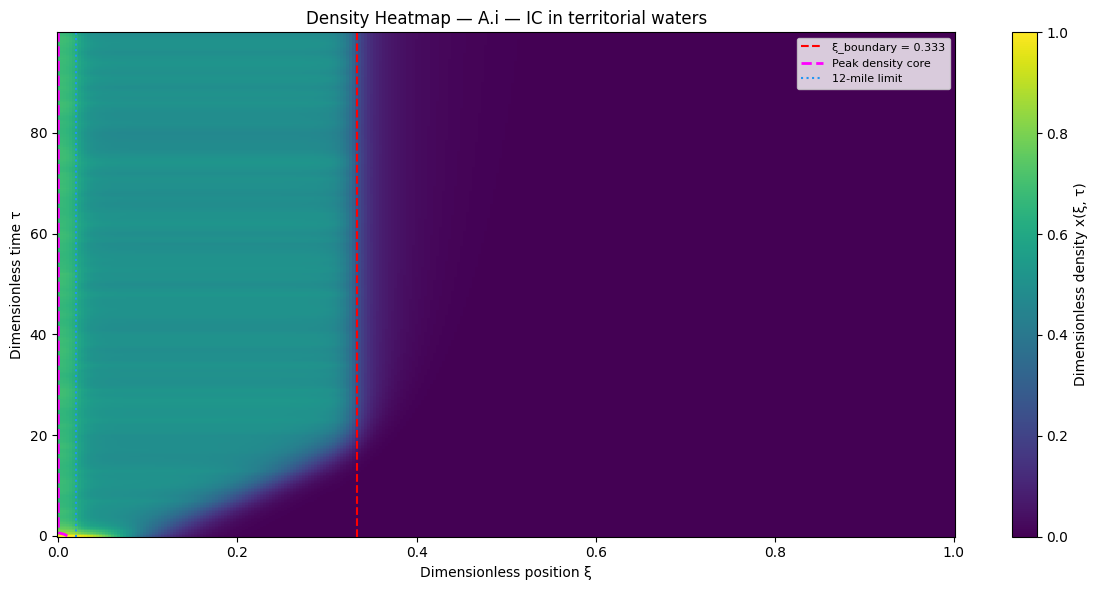

In [5]:
# A.i — Density snapshots
fig = plot_snapshots(res_Ai, title='A.i — IC in territorial waters', K=K)
ax = fig.axes[0]
add_zone_lines(ax)
ax.legend(fontsize=8, ncol=2)
plt.show()

# A.i — Regional biomass and catch
plot_3zone_biomass(res_Ai, 'A.i — IC in territorial waters')
plt.show()

# A.i — Heatmap with both zone boundaries
fig = plot_heatmap(
    res_Ai['s'], res_Ai['t_full'], res_Ai['u_full'],
    title='A.i — IC in territorial waters',
    s_boundary=xi_eez,
)
ax = fig.axes[0]
ax.axvline(xi_terr, color='#2196F3', ls=':', lw=1.5, label=f'12-mile limit')
ax.legend(loc='upper right', fontsize=8)
plt.show()

In [6]:
# ── A.ii  IC centred at s = 100 miles (EEZ) ──────────────────────────────────
res_Aii = simulate_rd_fishing_3zone(
    L=1.0, N=N,
    D=delta, r=1.0, K=K,
    T_end=T_end,
    s_boundary1=xi_terr,
    s_boundary2=xi_eez,
    h_terr_schedule=h_terr_A,
    h_eez_schedule=h_eez_A,
    h_intl=h_intl,
    gaussian_center=100.0/L_ref,   # ξ = 1/6
    gaussian_scale=50.0/L_ref,
    snapshot_times=snap_τ,
    store_full=True,
)
print(f"A.ii dt={res_Aii['dt']:.5f}  nt={res_Aii['nt']}  min(u)={res_Aii['min_u']:.4f}")

A.ii dt=0.04498  nt=2223  min(u)=0.0000


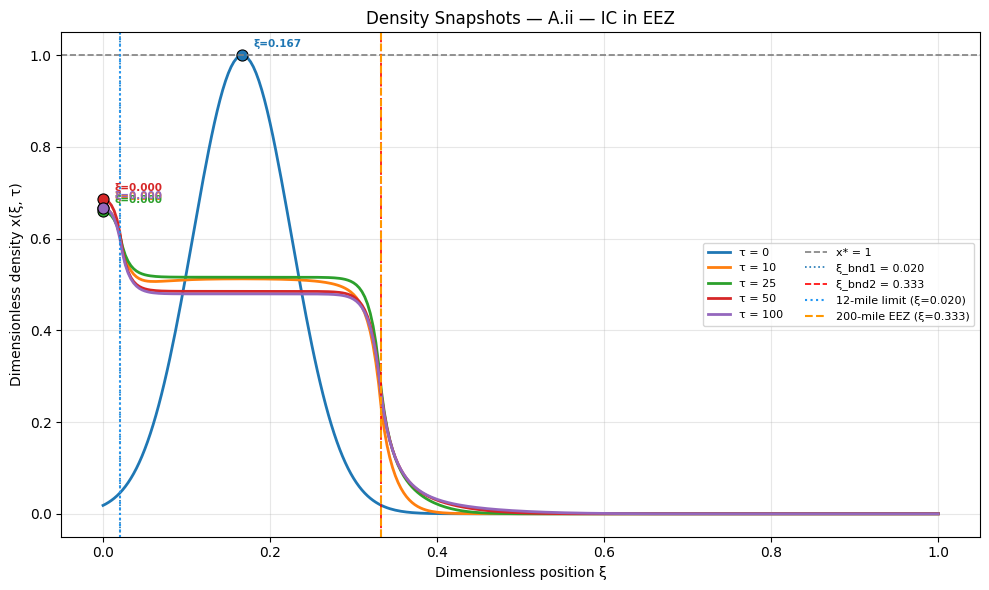

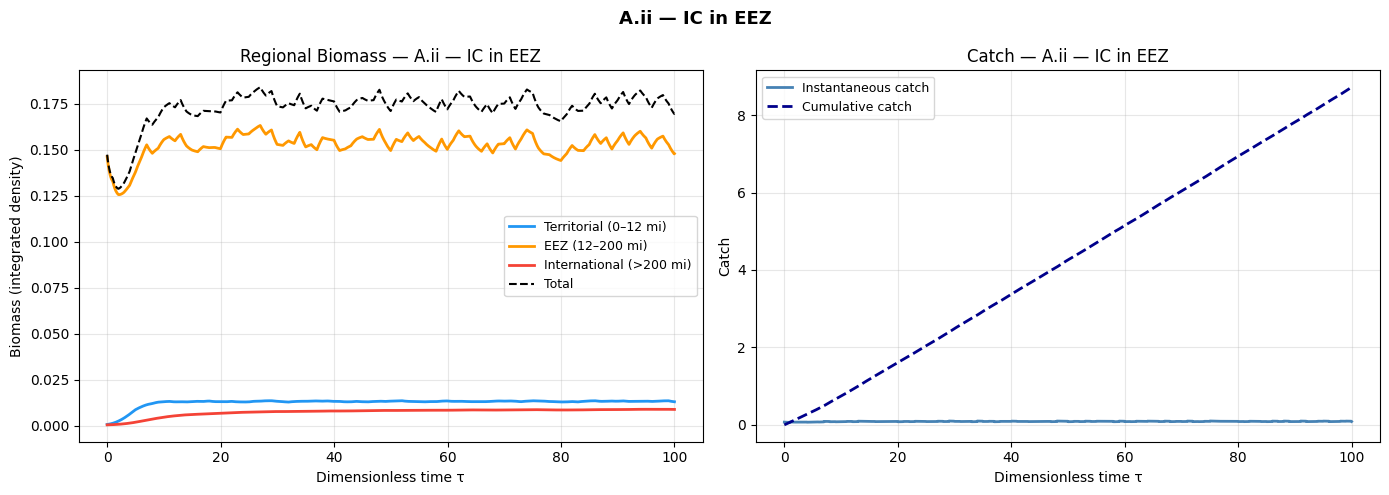

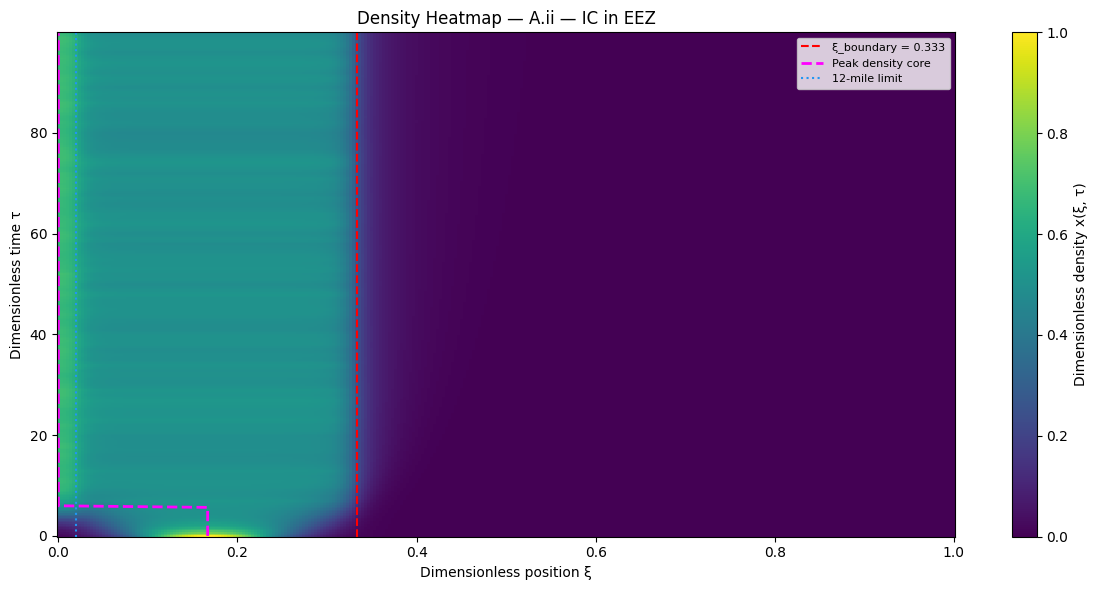

In [7]:
fig = plot_snapshots(res_Aii, title='A.ii — IC in EEZ', K=K)
add_zone_lines(fig.axes[0])
fig.axes[0].legend(fontsize=8, ncol=2)
plt.show()

plot_3zone_biomass(res_Aii, 'A.ii — IC in EEZ')
plt.show()

fig = plot_heatmap(
    res_Aii['s'], res_Aii['t_full'], res_Aii['u_full'],
    title='A.ii — IC in EEZ',
    s_boundary=xi_eez,
)
fig.axes[0].axvline(xi_terr, color='#2196F3', ls=':', lw=1.5, label='12-mile limit')
fig.axes[0].legend(loc='upper right', fontsize=8)
plt.show()

In [8]:
# ── A.iii  IC centred at s = 400 miles (international waters) ─────────────────
res_Aiii = simulate_rd_fishing_3zone(
    L=1.0, N=N,
    D=delta, r=1.0, K=K,
    T_end=T_end,
    s_boundary1=xi_terr,
    s_boundary2=xi_eez,
    h_terr_schedule=h_terr_A,
    h_eez_schedule=h_eez_A,
    h_intl=h_intl,
    gaussian_center=400.0/L_ref,   # ξ = 2/3
    gaussian_scale=50.0/L_ref,
    snapshot_times=snap_τ,
    store_full=True,
)
print(f"A.iii dt={res_Aiii['dt']:.5f}  nt={res_Aiii['nt']}  min(u)={res_Aiii['min_u']:.4f}")

A.iii dt=0.04498  nt=2223  min(u)=0.0000


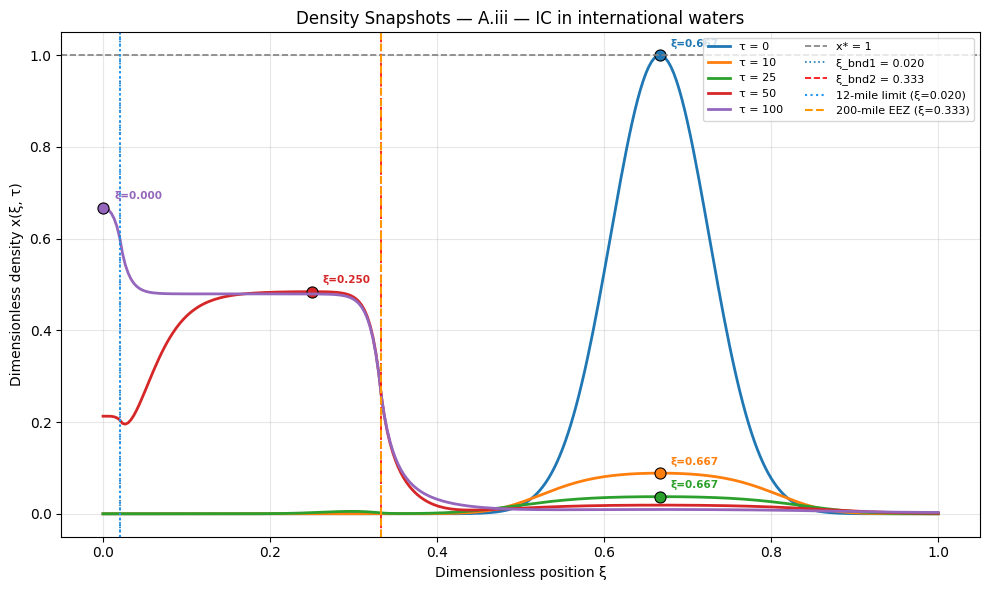

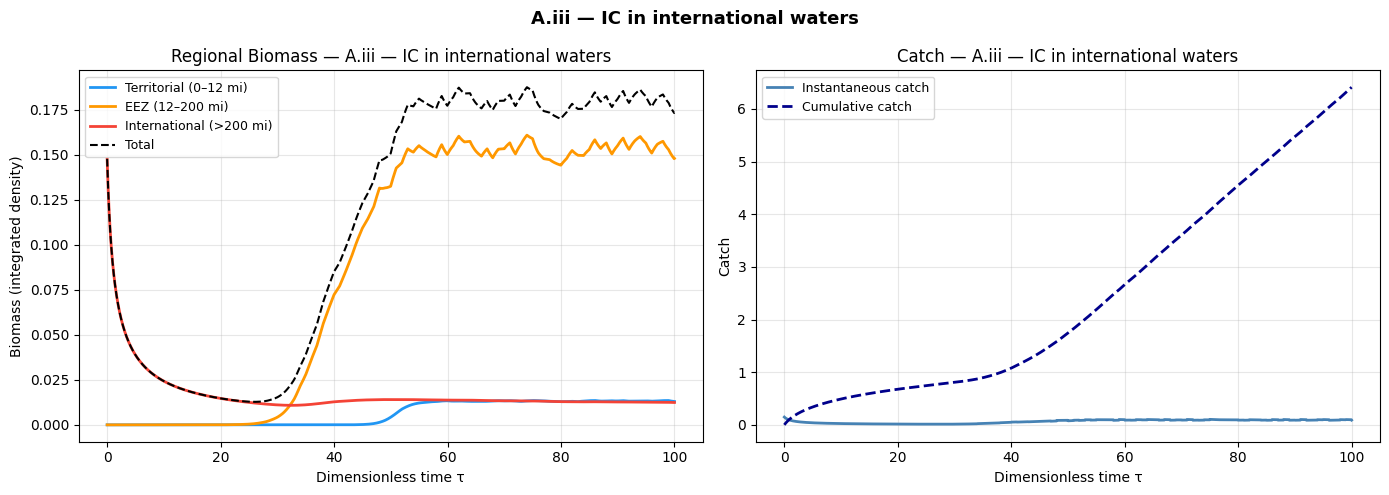

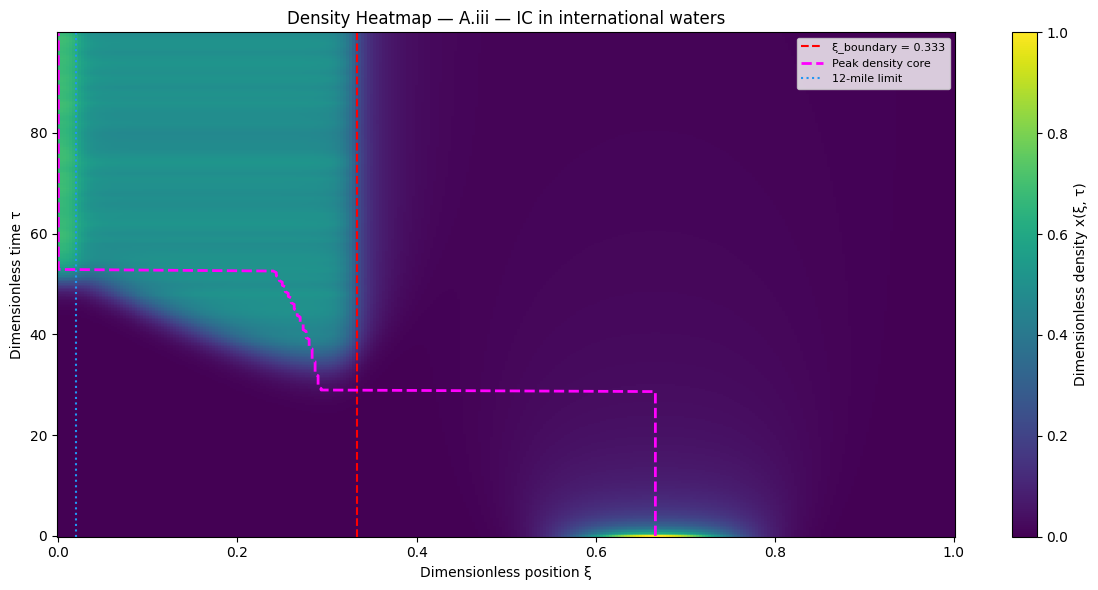

In [9]:
fig = plot_snapshots(res_Aiii, title='A.iii — IC in international waters', K=K)
add_zone_lines(fig.axes[0])
fig.axes[0].legend(fontsize=8, ncol=2)
plt.show()

plot_3zone_biomass(res_Aiii, 'A.iii — IC in international waters')
plt.show()

fig = plot_heatmap(
    res_Aiii['s'], res_Aiii['t_full'], res_Aiii['u_full'],
    title='A.iii — IC in international waters',
    s_boundary=xi_eez,
)
fig.axes[0].axvline(xi_terr, color='#2196F3', ls=':', lw=1.5, label='12-mile limit')
fig.axes[0].legend(loc='upper right', fontsize=8)
plt.show()

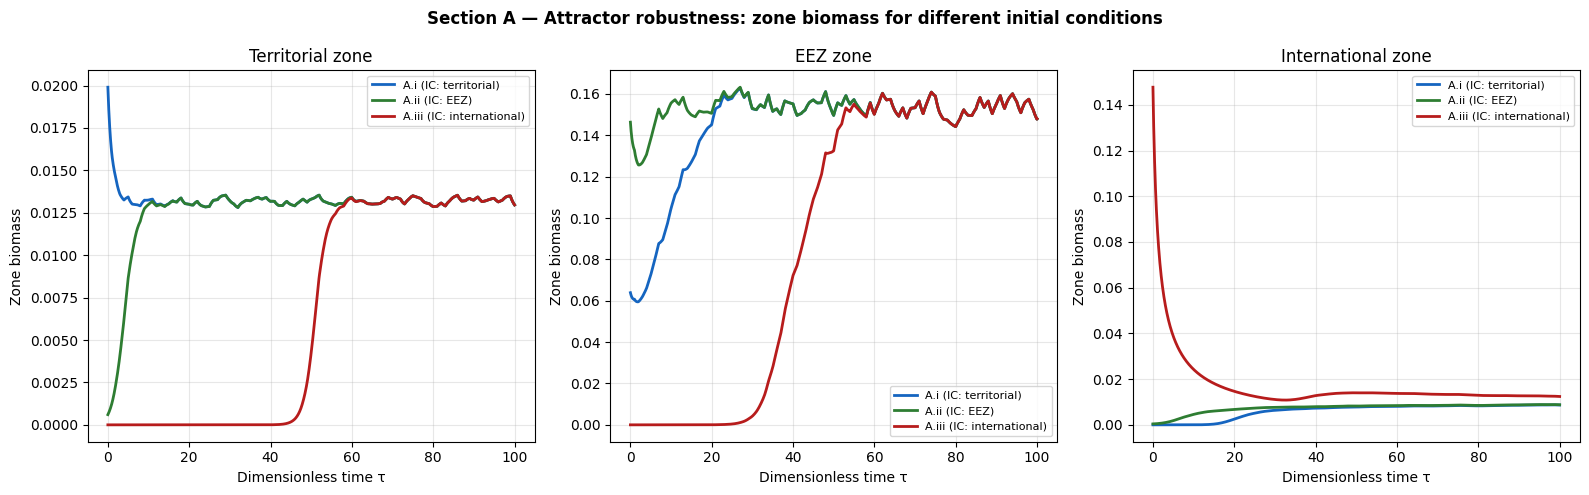

In [10]:
# ── Section A — Attractor comparison: total biomass across all three ICs ──────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ['A.i (IC: territorial)', 'A.ii (IC: EEZ)', 'A.iii (IC: international)']
results = [res_Ai, res_Aii, res_Aiii]
colors_ic = ['#1565C0', '#2E7D32', '#B71C1C']

for ax, (bkey, bname) in zip(
    axes,
    [('B_terr', 'Territorial'), ('B_eez', 'EEZ'), ('B_intl', 'International')]
):
    for res, lab, col in zip(results, labels, colors_ic):
        ax.plot(res['time'], res[bkey], color=col, lw=2, label=lab)
    ax.set_xlabel('Dimensionless time τ')
    ax.set_ylabel('Zone biomass')
    ax.set_title(f'{bname} zone')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    'Section A — Attractor robustness: zone biomass for different initial conditions',
    fontsize=12, fontweight='bold'
)
fig.tight_layout()
plt.show()

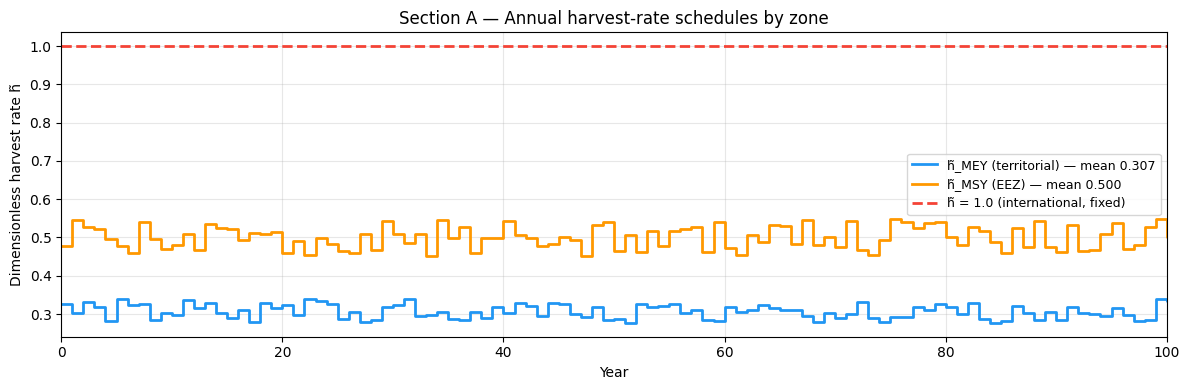

In [11]:
# ── Harvest-rate schedules ────────────────────────────────────────────────────
plot_harvest_schedule(h_terr_A, h_eez_A, h_intl, T_end,
                      title='Section A — Annual harvest-rate schedules by zone')
plt.show()

---
## Section B — Two Competing Species: Three-Zone Fishing Policy

PDEs (dimensionless):
$$\frac{\partial x}{\partial \tau} = x(1 - x - \beta_{12}\,y) - \tilde{h}_1(\xi,\tau)\,x + \delta_1\,\frac{\partial^2 x}{\partial \xi^2}$$
$$\frac{\partial y}{\partial \tau} = \rho\,y(1 - y - \beta_{21}\,x) - \tilde{h}_2(\xi,\tau)\,y + \delta_2\,\frac{\partial^2 y}{\partial \xi^2}$$

Same three-zone fishing policy applied independently to each species.
Competition is **balanced** (α = β = 0.5, K₁ = K₂ → β₁₂ = β₂₁ = 0.5).

**Sub-cases:**
- **B.i** — Species 1 at 6 mi (territorial), Species 2 at 100 mi (EEZ)
- **B.ii** — Species 1 at 100 mi (EEZ), Species 2 at 400 mi (international)
- **B.iii** — Both species at 200 mi (on the EEZ boundary)

In [12]:
# ── Section B shared parameters ───────────────────────────────────────────────
alpha_comp = 0.5   # effect of species 2 on species 1
beta_comp  = 0.5   # effect of species 1 on species 2
D1, D2     = delta, delta
r1, r2     = 1.0, 1.0
K1, K2     = 1.0, 1.0

# Separate stochastic schedules for two species
h1_terr_B = make_mey_schedule(n_years, rng)
h1_eez_B  = make_msy_schedule(n_years, rng)
h2_terr_B = make_mey_schedule(n_years, rng)
h2_eez_B  = make_msy_schedule(n_years, rng)

print('Section B schedules generated.')
print(f"Species 1 MEY mean={h1_terr_B.mean():.4f}  MSY mean={h1_eez_B.mean():.4f}")
print(f"Species 2 MEY mean={h2_terr_B.mean():.4f}  MSY mean={h2_eez_B.mean():.4f}")

Section B schedules generated.
Species 1 MEY mean=0.3055  MSY mean=0.5034
Species 2 MEY mean=0.3068  MSY mean=0.5006


In [13]:
# ── B.i  Sp1 at 6 mi, Sp2 at 100 mi ──────────────────────────────────────────
res_Bi = simulate_competing_rd_fishing_3zone(
    L=1.0, N=N,
    D1=D1, D2=D2,
    r1=r1, r2=r2,
    K1=K1, K2=K2,
    alpha=alpha_comp, beta=beta_comp,
    T_end=T_end,
    s_boundary1=xi_terr, s_boundary2=xi_eez,
    h1_terr_schedule=h1_terr_B, h1_eez_schedule=h1_eez_B,
    h2_terr_schedule=h2_terr_B, h2_eez_schedule=h2_eez_B,
    h_intl=h_intl,
    u0_gaussian_center=6.0/L_ref,
    u0_gaussian_scale=50.0/L_ref,
    v0_gaussian_center=100.0/L_ref,
    v0_gaussian_scale=50.0/L_ref,
    snapshot_times=snap_τ,
    store_full=True,
)
print(f"B.i  dt={res_Bi['dt']:.5f}  nt={res_Bi['nt']}")

B.i  dt=0.04498  nt=2223


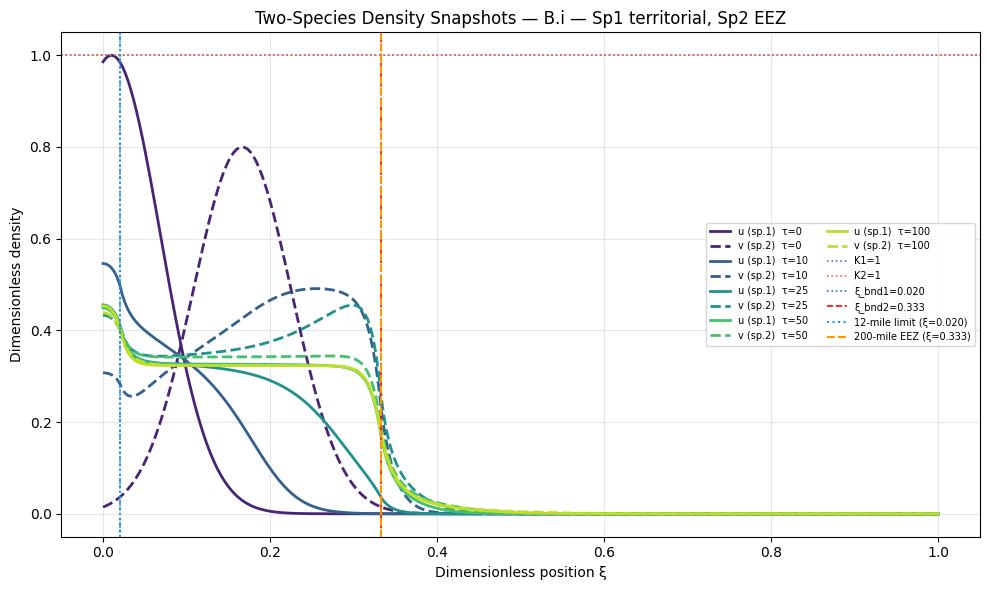

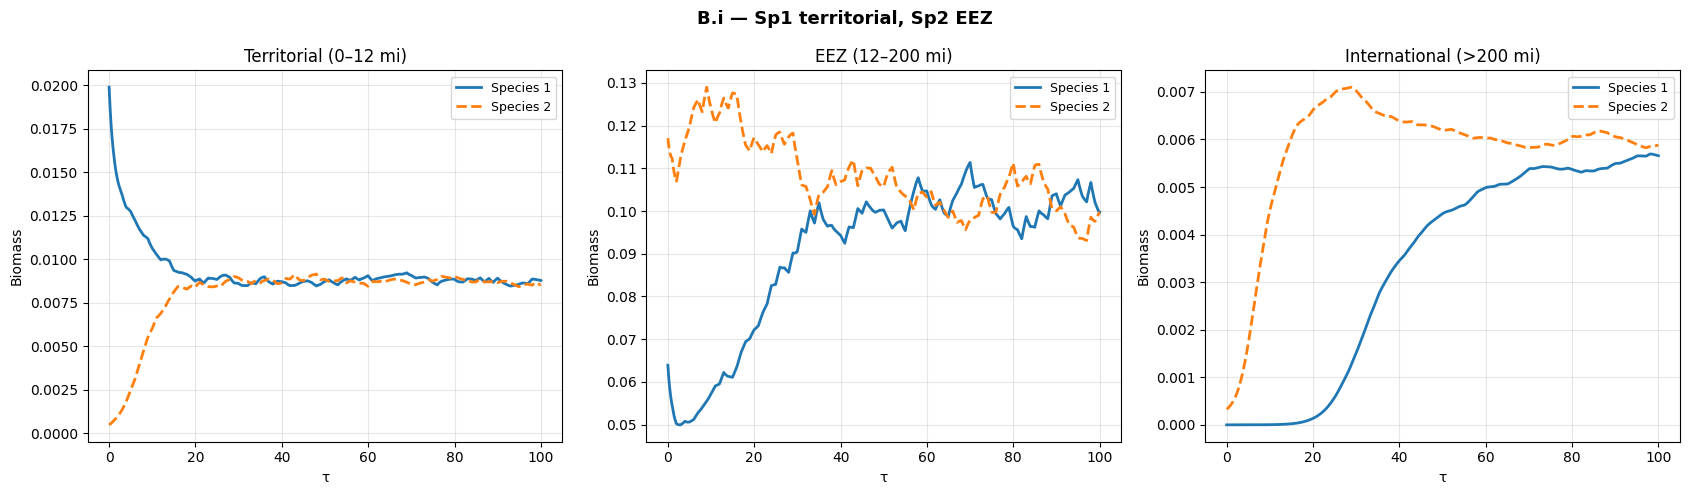

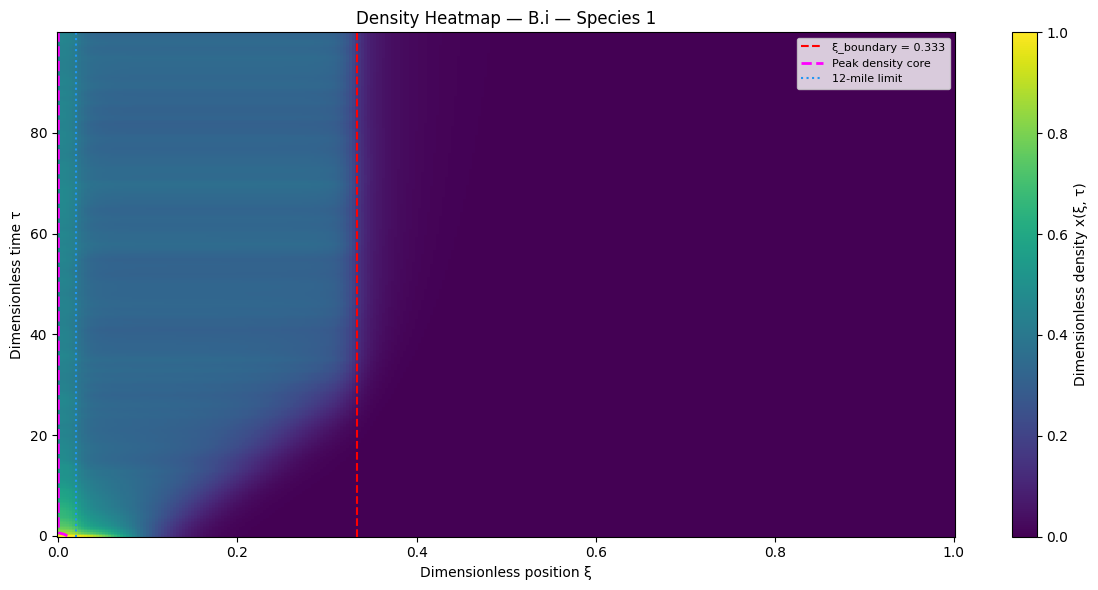

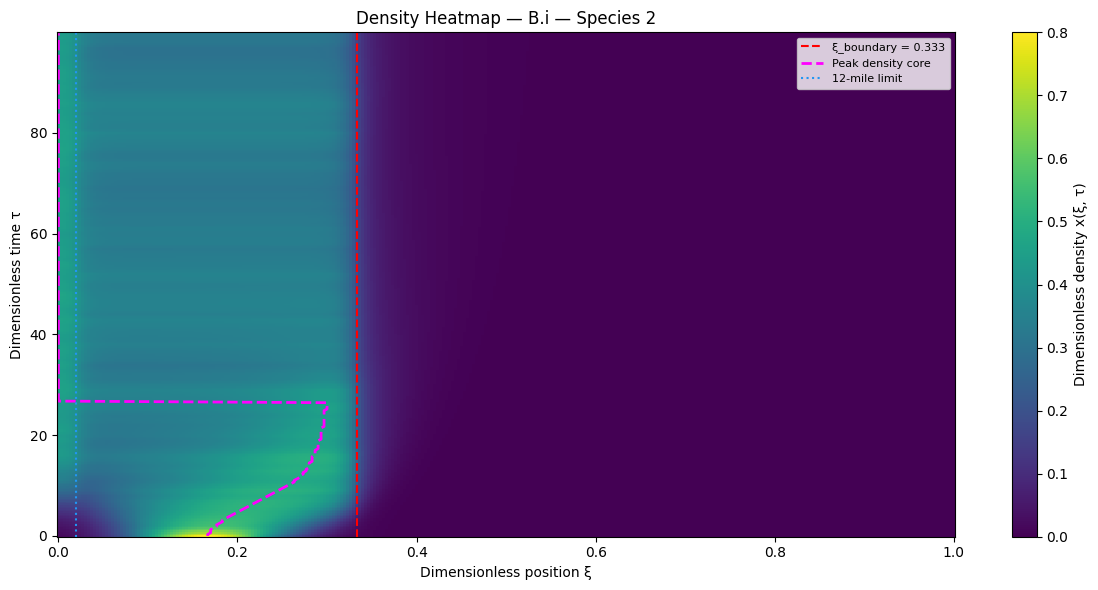

In [14]:
fig = plot_snapshots_2s(res_Bi, title='B.i — Sp1 territorial, Sp2 EEZ', K1=K1, K2=K2)
add_zone_lines(fig.axes[0])
fig.axes[0].legend(fontsize=7, ncol=2)
plt.show()

plot_3zone_biomass_2s(res_Bi, 'B.i — Sp1 territorial, Sp2 EEZ')
plt.show()

# Heatmaps for each species
for u_arr, sp_label in [(res_Bi['u_full'], 'Species 1'), (res_Bi['v_full'], 'Species 2')]:
    fig = plot_heatmap(res_Bi['s'], res_Bi['t_full'], u_arr,
                       title=f'B.i — {sp_label}', s_boundary=xi_eez)
    fig.axes[0].axvline(xi_terr, color='#2196F3', ls=':', lw=1.5, label='12-mile limit')
    fig.axes[0].legend(loc='upper right', fontsize=8)
    plt.show()

In [15]:
# ── B.ii  Sp1 at 100 mi (EEZ), Sp2 at 400 mi (international) ─────────────────
res_Bii = simulate_competing_rd_fishing_3zone(
    L=1.0, N=N,
    D1=D1, D2=D2,
    r1=r1, r2=r2,
    K1=K1, K2=K2,
    alpha=alpha_comp, beta=beta_comp,
    T_end=T_end,
    s_boundary1=xi_terr, s_boundary2=xi_eez,
    h1_terr_schedule=h1_terr_B, h1_eez_schedule=h1_eez_B,
    h2_terr_schedule=h2_terr_B, h2_eez_schedule=h2_eez_B,
    h_intl=h_intl,
    u0_gaussian_center=100.0/L_ref,
    u0_gaussian_scale=50.0/L_ref,
    v0_gaussian_center=400.0/L_ref,
    v0_gaussian_scale=50.0/L_ref,
    snapshot_times=snap_τ,
    store_full=True,
)
print(f"B.ii dt={res_Bii['dt']:.5f}  nt={res_Bii['nt']}")

B.ii dt=0.04498  nt=2223


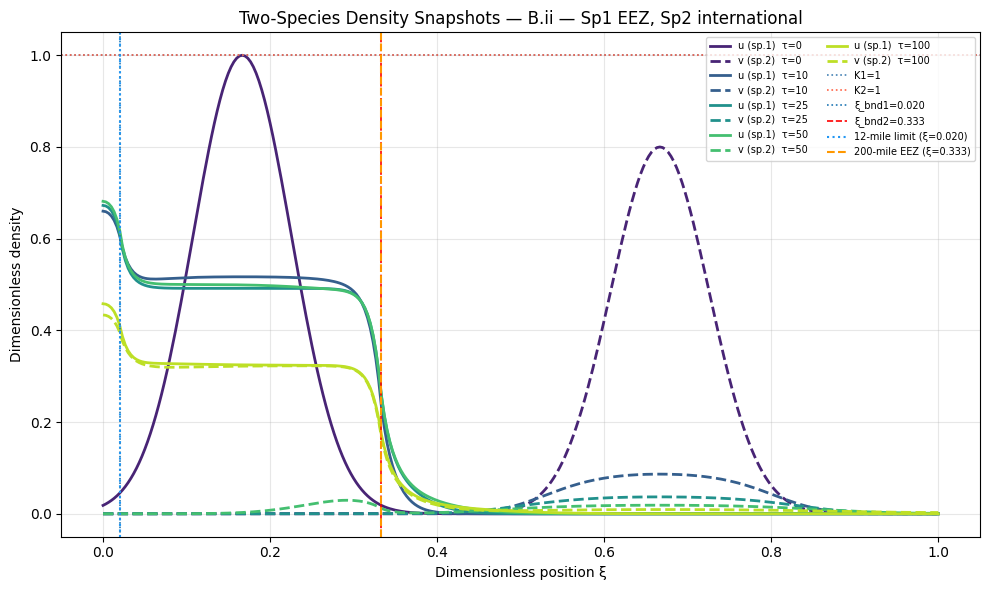

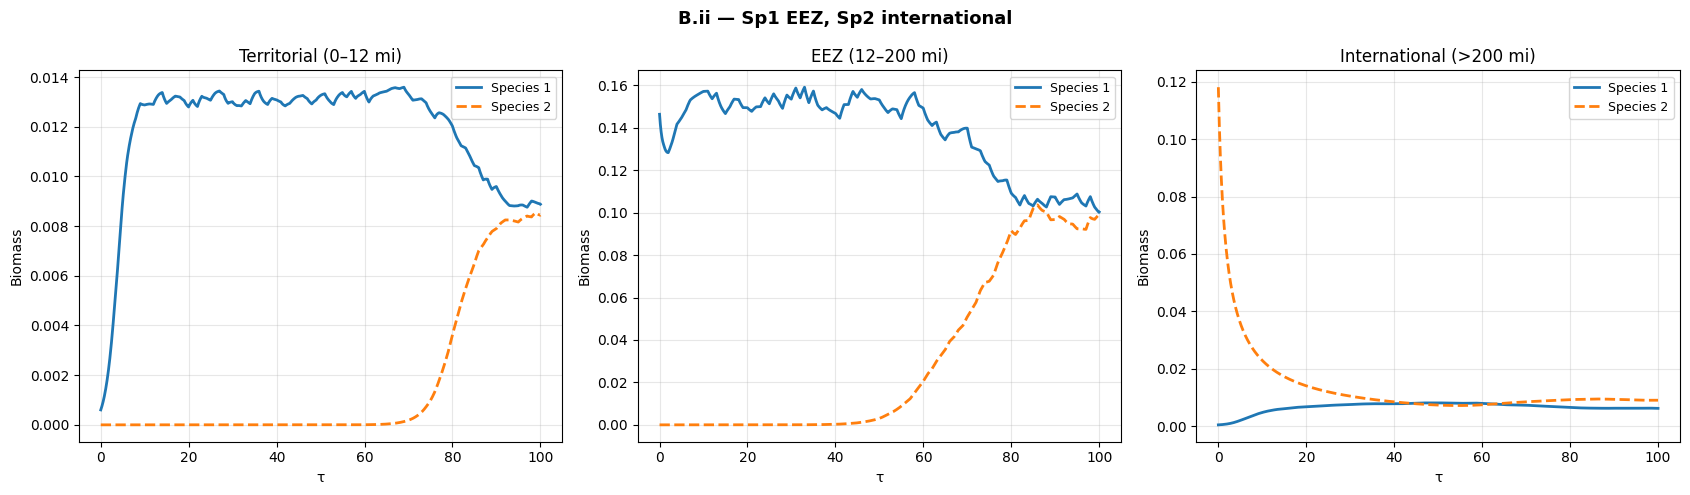

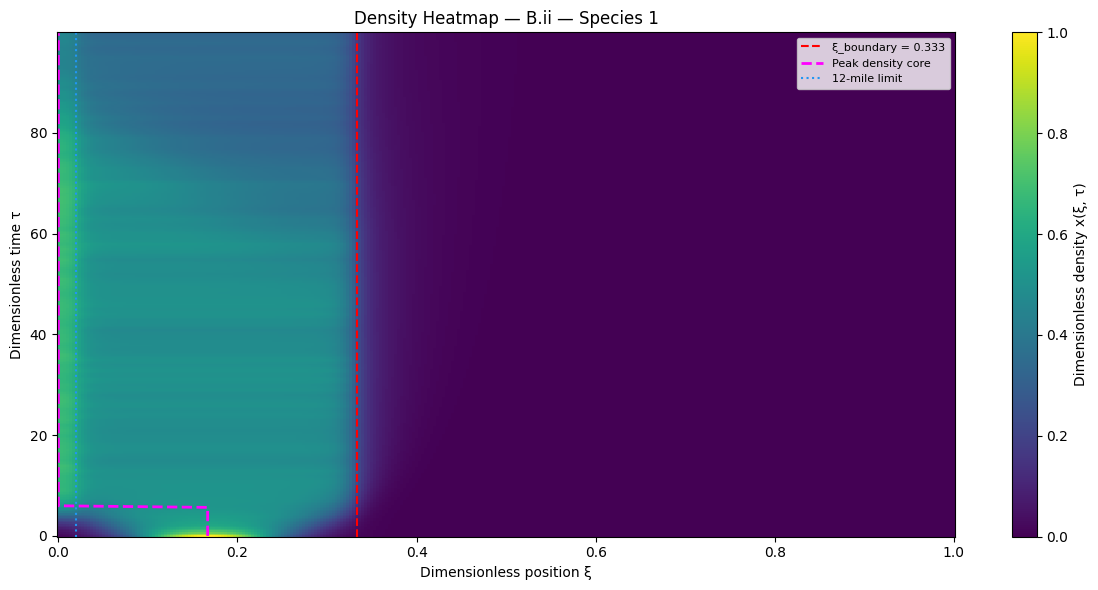

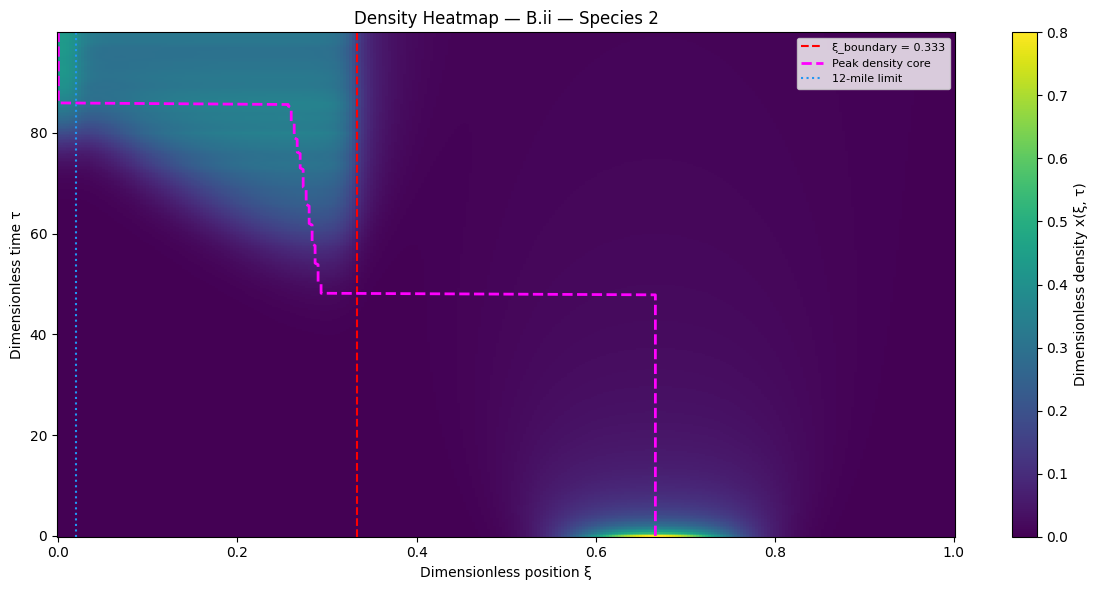

In [16]:
fig = plot_snapshots_2s(res_Bii, title='B.ii — Sp1 EEZ, Sp2 international', K1=K1, K2=K2)
add_zone_lines(fig.axes[0])
fig.axes[0].legend(fontsize=7, ncol=2)
plt.show()

plot_3zone_biomass_2s(res_Bii, 'B.ii — Sp1 EEZ, Sp2 international')
plt.show()

for u_arr, sp_label in [(res_Bii['u_full'], 'Species 1'), (res_Bii['v_full'], 'Species 2')]:
    fig = plot_heatmap(res_Bii['s'], res_Bii['t_full'], u_arr,
                       title=f'B.ii — {sp_label}', s_boundary=xi_eez)
    fig.axes[0].axvline(xi_terr, color='#2196F3', ls=':', lw=1.5, label='12-mile limit')
    fig.axes[0].legend(loc='upper right', fontsize=8)
    plt.show()

In [17]:
# ── B.iii  Both species at 200 mi (EEZ boundary) ─────────────────────────────
res_Biii = simulate_competing_rd_fishing_3zone(
    L=1.0, N=N,
    D1=D1, D2=D2,
    r1=r1, r2=r2,
    K1=K1, K2=K2,
    alpha=alpha_comp, beta=beta_comp,
    T_end=T_end,
    s_boundary1=xi_terr, s_boundary2=xi_eez,
    h1_terr_schedule=h1_terr_B, h1_eez_schedule=h1_eez_B,
    h2_terr_schedule=h2_terr_B, h2_eez_schedule=h2_eez_B,
    h_intl=h_intl,
    u0_gaussian_center=200.0/L_ref,
    u0_gaussian_scale=50.0/L_ref,
    v0_gaussian_center=200.0/L_ref,
    v0_gaussian_scale=60.0/L_ref,
    snapshot_times=snap_τ,
    store_full=True,
)
print(f"B.iii dt={res_Biii['dt']:.5f}  nt={res_Biii['nt']}")

B.iii dt=0.04498  nt=2223


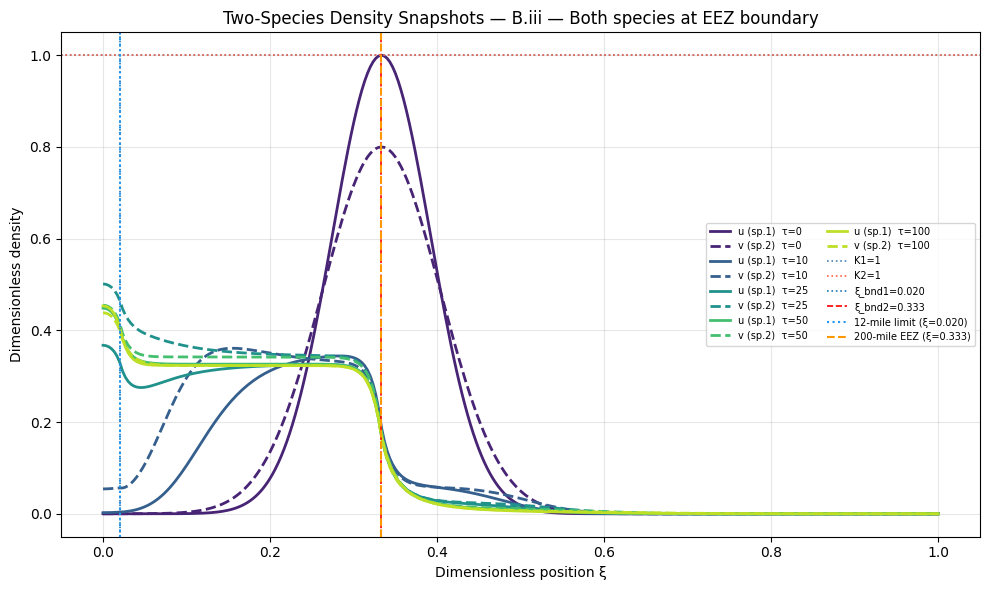

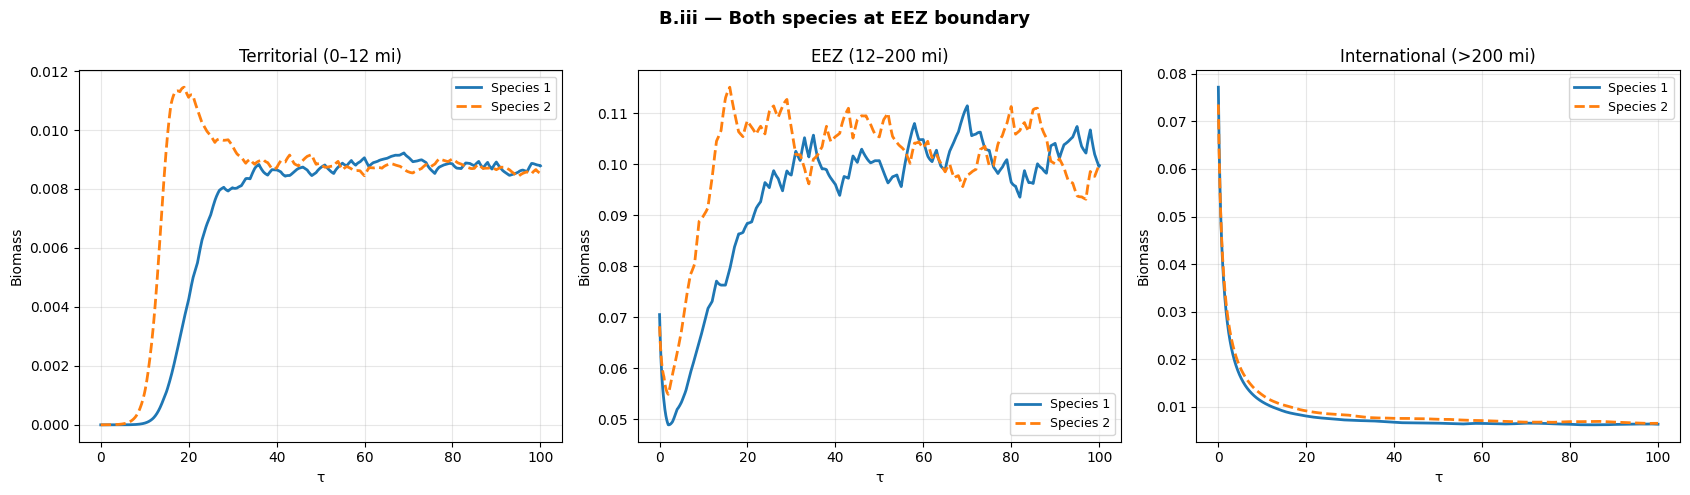

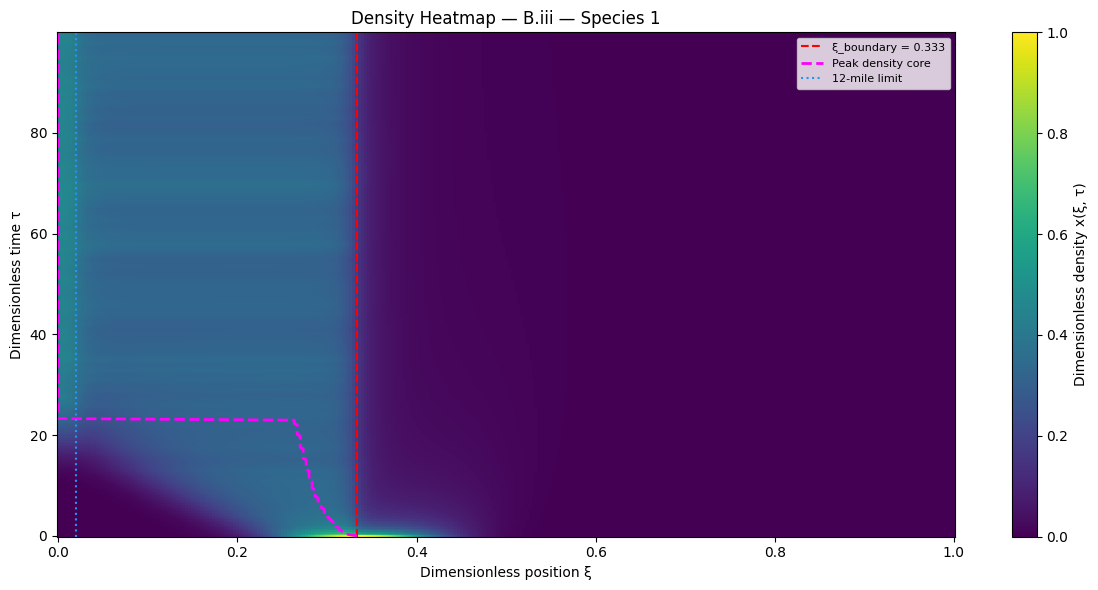

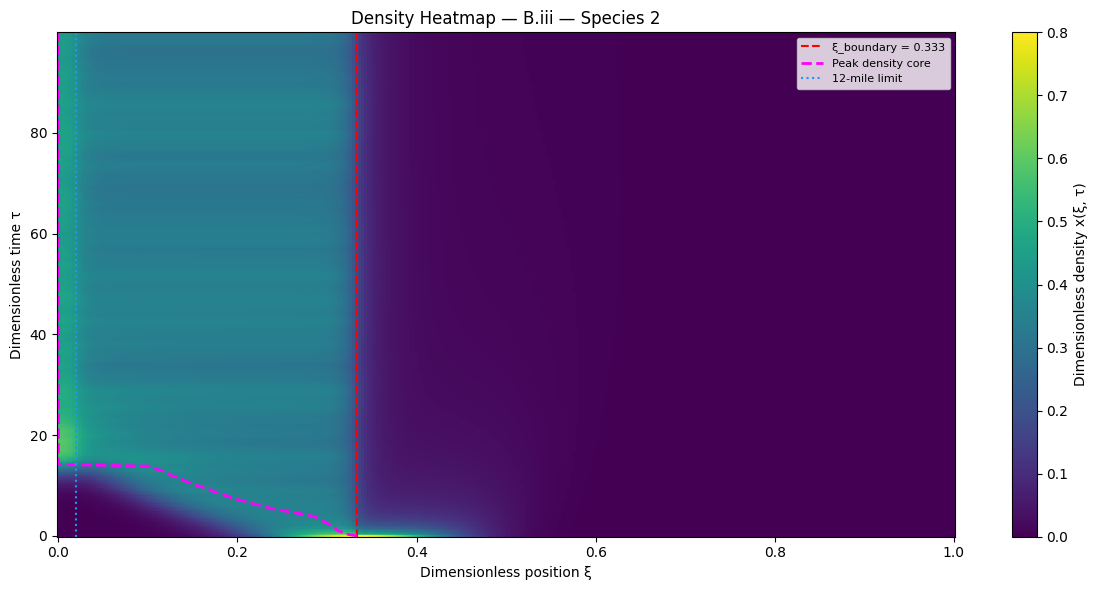

In [18]:
fig = plot_snapshots_2s(res_Biii, title='B.iii — Both species at EEZ boundary', K1=K1, K2=K2)
add_zone_lines(fig.axes[0])
fig.axes[0].legend(fontsize=7, ncol=2)
plt.show()

plot_3zone_biomass_2s(res_Biii, 'B.iii — Both species at EEZ boundary')
plt.show()

for u_arr, sp_label in [(res_Biii['u_full'], 'Species 1'), (res_Biii['v_full'], 'Species 2')]:
    fig = plot_heatmap(res_Biii['s'], res_Biii['t_full'], u_arr,
                       title=f'B.iii — {sp_label}', s_boundary=xi_eez)
    fig.axes[0].axvline(xi_terr, color='#2196F3', ls=':', lw=1.5, label='12-mile limit')
    fig.axes[0].legend(loc='upper right', fontsize=8)
    plt.show()